<a href="https://colab.research.google.com/github/rajanaids-hub/BASICS-ML/blob/main/linear_regression_hands_on.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple Linear Regression — Hands-On Notebook
### Course: U23ADT306 – Basic Machine Learning Techniques (B.Tech AI & DS, Semester 3)

**Learning Objectives**
- Understand the intuition and math behind Simple Linear Regression (one feature -> one target)
- Perform Exploratory Data Analysis (EDA) on a real-world dataset
- Preprocess data correctly for a regression task
- Train a Linear Regression model using scikit-learn (and understand the "from scratch" version)
- Evaluate a regression model using R², MAE, and RMSE
- Interpret the trained model's coefficients

**Dataset:** Salary vs Years of Experience
**Source (mirror):** https://raw.githubusercontent.com/krishnaik06/simple-Linear-Regression/master/Salary_Data.csv
(Originally distributed as a well-known open dataset on Kaggle/UCI-style ML course repositories:
"Salary_Data.csv" — 30 rows, 2 columns: `YearsExperience`, `Salary`)

**Estimated time:** 45–60 minutes


## 1. Environment Setup
Run this cell once to make sure every required library is installed.

In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# Before we can load data, plot graphs, or train a model, we need the
# correct Python libraries installed in this environment (VS Code's
# Jupyter kernel). This cell installs them if missing so the notebook
# runs the same way on any machine (reproducibility).
# ------------------------------------------------------------------
import sys                     # sys -> lets us call the current Python interpreter for pip installs
import subprocess               # subprocess -> lets us run shell commands (pip install) from inside Python

# List of packages required for this notebook (equivalent to requirements.txt)
required_packages = [
    "pandas",        # for loading and manipulating tabular data (DataFrames)
    "numpy",         # for numerical operations and arrays
    "scikit-learn",  # for the LinearRegression model and train/test split utilities
    "matplotlib",    # for plotting graphs
    "seaborn",       # for nicer statistical plots (heatmaps, distribution plots)
    "requests"       # for downloading the dataset directly from a URL
]

# Loop through each package and install it quietly (-q) if not already present
# --break-system-packages is safe to include -- pip ignores it on environments
# that don't need it (e.g. conda, venv) and it prevents install failures on
# newer Debian/Ubuntu based systems that lock the system Python.
for package in required_packages:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "--break-system-packages", package]
    )  # install package silently

print("All required packages are installed.")  # confirmation message for the student


All required packages are installed.


## 2. Dataset Download + Loading
We use the classic **Salary_Data.csv** dataset (Years of Experience -> Salary).
It mirrors the well-known Kaggle "Salary Prediction" dataset used in almost every
introductory Linear Regression course.

If your machine has the Kaggle CLI configured, you could alternatively run:
```
# import kagglehub
# path = kagglehub.dataset_download("abhishek14398/salary-dataset-simple-linear-regression")
```
To keep this notebook runnable for every student without needing a Kaggle account/API key,
we download the same data directly from a public GitHub CSV mirror instead.


In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# We need the actual data in memory before we can explore or model it.
# We download a real-world CSV file directly from a public URL so that
# every student gets the exact same data without manual uploads.
# ------------------------------------------------------------------
import pandas as pd   # pandas -> library for reading CSV files into DataFrames (table-like structures)

# Public raw-CSV mirror of the Salary_Data dataset (no login/API key required)
DATA_URL = "https://raw.githubusercontent.com/krishnaik06/simple-Linear-Regression/master/Salary_Data.csv"

# pd.read_csv() downloads and parses the CSV directly from the URL into a DataFrame
salary_df = pd.read_csv(DATA_URL)   # salary_df -> our main dataset (short for "salary dataframe")

# Display the first 5 rows so we can visually confirm the data loaded correctly
salary_df.head()   # .head() -> shows first 5 rows; helps quickly sanity-check column names and values


,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


## 3. Exploratory Data Analysis (EDA)
Before modeling, we must understand the shape, quality, and distribution of the data.

In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# We check the size and data types of the dataset. This tells us how many
# rows (samples) and columns (features) we have, and whether any column
# has the wrong data type (e.g. numbers stored as text).
# ------------------------------------------------------------------
print("Shape of dataset (rows, columns):", salary_df.shape)   # .shape -> tuple (num_rows, num_columns)
print()
print("Data types of each column:")
print(salary_df.dtypes)   # .dtypes -> shows whether each column is int, float, or object(text)


Shape of dataset (rows, columns): (30, 2)

Data types of each column:
YearsExperience    float64
Salary             float64
dtype: object


In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# Missing values can break model training or bias results. We must check
# for them before proceeding.
# ------------------------------------------------------------------
missing_values_per_column = salary_df.isnull().sum()   # isnull() -> True/False per cell; sum() -> count per column
print("Missing values per column:")
print(missing_values_per_column)   # if all zeros, the dataset is complete and needs no imputation


Missing values per column:
YearsExperience    0
Salary             0
dtype: int64


In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# Summary statistics (mean, std, min, max, quartiles) give a quick feel
# for the scale and spread of each numeric column, helping us spot
# outliers or unusual values early.
# ------------------------------------------------------------------
salary_df.describe()   # .describe() -> count, mean, std, min, 25/50/75%, max for every numeric column


,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


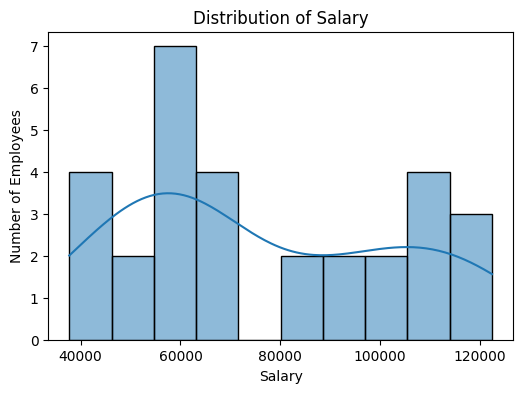

In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# Visualization #1: Distribution plot.
# We look at how "Salary" values are spread out, to check for skew
# or unusual clustering before we model it.
# ------------------------------------------------------------------
import matplotlib.pyplot as plt   # matplotlib.pyplot -> core plotting library
import seaborn as sns             # seaborn -> statistical plotting built on top of matplotlib

plt.figure(figsize=(6, 4))                          # figsize -> width=6in, height=4in, chosen for readability
sns.histplot(salary_df["Salary"], bins=10, kde=True) # bins=10 -> group data into 10 bars; kde=True -> smooth density curve
plt.title("Distribution of Salary")                 # title explains what the plot shows
plt.xlabel("Salary")                                 # x-axis label
plt.ylabel("Number of Employees")                    # y-axis label
plt.show()   # renders the plot in the notebook

# WHAT TO OBSERVE: Check whether salaries are roughly spread across the range
# or clustered heavily at one end (which would indicate skewed data).


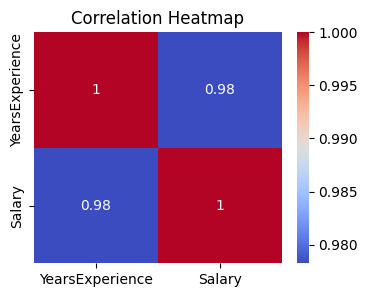

In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# Visualization #2: Correlation heatmap.
# For a 2-column dataset this simply confirms how strongly Salary and
# YearsExperience move together (correlation close to +1 means strong
# positive linear relationship -- exactly what Linear Regression assumes).
# ------------------------------------------------------------------
plt.figure(figsize=(4, 3))                                    # smaller figure since only 2 variables
correlation_matrix = salary_df.corr()                          # .corr() -> pairwise correlation coefficients (-1 to 1)
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")   # annot=True -> print numeric values on cells
plt.title("Correlation Heatmap")
plt.show()

# WHAT TO OBSERVE: A correlation near +0.9 or higher between YearsExperience
# and Salary tells us Linear Regression is a suitable model choice here.


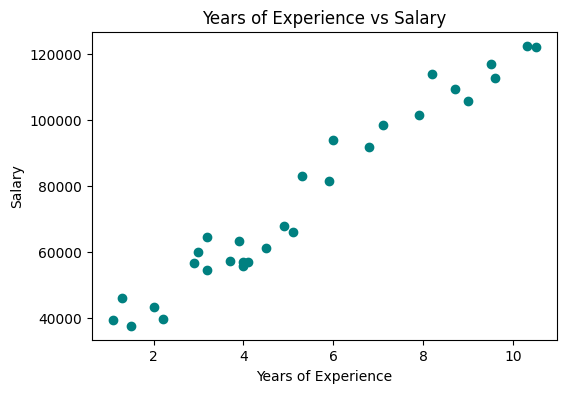

In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# Visualization #3: Scatter plot.
# This is the most direct way to see the relationship Linear Regression
# is going to try to model with a straight line.
# ------------------------------------------------------------------
plt.figure(figsize=(6, 4))
plt.scatter(salary_df["YearsExperience"], salary_df["Salary"], color="teal")  # raw data points
plt.title("Years of Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

# WHAT TO OBSERVE: The points should roughly follow a straight upward line --
# this visually confirms a linear relationship exists between the two variables.


## 4. Data Preprocessing
Even though this dataset is already clean, we still follow the standard ML
pipeline steps so the workflow generalizes to messier real-world datasets.


In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# We separate the dataset into:
#   X -> the input feature(s) the model learns FROM
#   y -> the target value the model tries to PREDICT
# This split is required before we can train any scikit-learn model.
# ------------------------------------------------------------------
import numpy as np   # numpy -> needed for array reshaping operations below

# X must be a 2D array (rows=samples, columns=features) -- scikit-learn requires this shape
X = salary_df[["YearsExperience"]].values   # double brackets keep it as a DataFrame -> 2D numpy array
# y is the target column; scikit-learn expects this as a 1D array
y = salary_df["Salary"].values              # single brackets -> Series -> 1D numpy array

print("X shape:", X.shape)   # expect (30, 1) -> 30 samples, 1 feature
print("y shape:", y.shape)   # expect (30,)  -> 30 target values


X shape: (30, 1)
y shape: (30,)


In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# We split data into a TRAINING set (model learns from this) and a TEST
# set (used only to evaluate the model on unseen data). This prevents us
# from fooling ourselves into thinking the model generalizes well when it
# has only memorized the training data.
# ------------------------------------------------------------------
from sklearn.model_selection import train_test_split   # utility function for splitting data

# test_size=0.2 -> keep 80% of rows for training, hold out 20% for unbiased testing
# random_state=42 -> fixes the random shuffle so results are reproducible every run
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])   # how many rows the model will learn from
print("Testing samples:", X_test.shape[0])      # how many rows are reserved for evaluation


Training samples: 24
Testing samples: 6


## 5. Model Building
First we implement Linear Regression "from scratch" using the Normal Equation,
just to demystify the math. Then we use scikit-learn's production-ready version.


In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS (OPTIONAL "FROM SCRATCH" SECTION):
# Linear Regression fits a line: y = m*x + c (slope m, intercept c).
# The Normal Equation gives us the exact best-fit m and c directly,
# without needing iterative gradient descent, for small datasets like this.
# Formula (matrix form): theta = (X_b^T . X_b)^-1 . X_b^T . y
# ------------------------------------------------------------------
X_b_train = np.c_[np.ones((X_train.shape[0], 1)), X_train]  # np.c_ -> add a column of 1s for the intercept term

# theta will contain [intercept, slope] after this calculation
theta_best = np.linalg.inv(X_b_train.T.dot(X_b_train)).dot(X_b_train.T).dot(y_train)
# np.linalg.inv -> matrix inverse; .T -> transpose; .dot -> matrix multiplication

intercept_scratch = theta_best[0]   # the 'c' in y = m*x + c
slope_scratch = theta_best[1]       # the 'm' in y = m*x + c

print(f"From-scratch model: Salary = {slope_scratch:.2f} * YearsExperience + {intercept_scratch:.2f}")
# INTERPRETATION: This equation is our manually-derived best-fit line, and it
# should closely match scikit-learn's result in the next cell.


From-scratch model: Salary = 9423.82 * YearsExperience + 25321.58


In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# We now train the same model using scikit-learn, the industry-standard
# library, which is faster, tested, and handles edge cases automatically.
# ------------------------------------------------------------------
from sklearn.linear_model import LinearRegression   # the model class we will use

linear_model = LinearRegression()    # create an (untrained) Linear Regression object
linear_model.fit(X_train, y_train)   # .fit() -> learns the best-fit slope and intercept from training data

print(f"scikit-learn model: Salary = {linear_model.coef_[0]:.2f} * YearsExperience + {linear_model.intercept_:.2f}")
# INTERPRETATION: coef_[0] is the slope (change in salary per extra year of
# experience); intercept_ is the predicted salary at 0 years of experience.


scikit-learn model: Salary = 9423.82 * YearsExperience + 25321.58


## 6. Evaluation
We measure how well the model predicts SALARY on the held-out TEST set.

In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# We use the trained model to predict salaries for the test set, then
# compare predictions against the true values using standard regression
# metrics: R², MAE, and RMSE.
# ------------------------------------------------------------------
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

y_pred = linear_model.predict(X_test)   # predict salaries for the unseen test set

r2 = r2_score(y_test, y_pred)                     # R^2 -> proportion of variance explained (1.0 = perfect)
mae = mean_absolute_error(y_test, y_pred)         # MAE -> average absolute prediction error, in same units as Salary
rmse = np.sqrt(mean_squared_error(y_test, y_pred))# RMSE -> penalizes large errors more heavily than MAE

print(f"R^2 Score : {r2:.4f}   (closer to 1.0 is better; >0.9 is considered a strong fit here)")
print(f"MAE       : {mae:.2f} (average dollar error per prediction; lower is better)")
print(f"RMSE      : {rmse:.2f} (larger errors are penalized more; lower is better)")


R^2 Score : 0.9024   (closer to 1.0 is better; >0.9 is considered a strong fit here)
MAE       : 6286.45 (average dollar error per prediction; lower is better)
RMSE      : 7059.04 (larger errors are penalized more; lower is better)


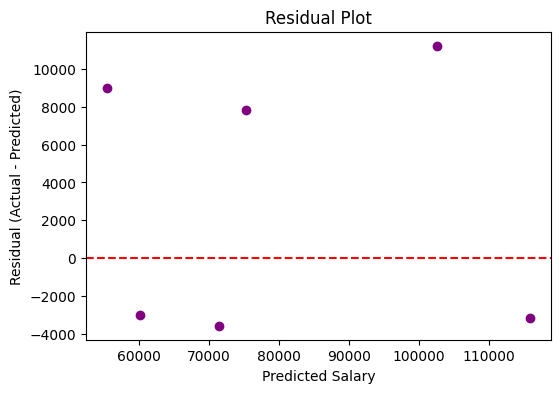

In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# A residual plot shows prediction errors (actual - predicted). Randomly
# scattered residuals around zero indicate the linear model is appropriate;
# a clear pattern would suggest a non-linear relationship instead.
# ------------------------------------------------------------------
residuals = y_test - y_pred   # residual = actual value - predicted value, per test sample

plt.figure(figsize=(6, 4))
plt.scatter(y_pred, residuals, color="purple")
plt.axhline(y=0, color="red", linestyle="--")   # reference line at residual=0 (perfect prediction)
plt.title("Residual Plot")
plt.xlabel("Predicted Salary")
plt.ylabel("Residual (Actual - Predicted)")
plt.show()

# WHAT TO OBSERVE: Points should be randomly scattered around the red dashed
# line with no obvious curve or funnel shape -- confirming a linear fit is valid.


## 7. Interpretation

In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# We translate the mathematical coefficients into a plain-English business
# statement that a non-technical stakeholder (e.g. HR manager) could understand.
# ------------------------------------------------------------------
slope = linear_model.coef_[0]        # dollars gained in salary per extra year of experience
intercept = linear_model.intercept_  # baseline predicted salary at 0 years experience

print(f"Plain-English interpretation:")
print(f"- For every additional year of experience, predicted salary increases by ${slope:,.2f}.")
print(f"- An employee with 0 years of experience is predicted to earn ${intercept:,.2f}.")


Plain-English interpretation:


- For every additional year of experience, predicted salary increases by $9,423.82.
- An employee with 0 years of experience is predicted to earn $25,321.58.


## 8. Practice Exercises (No Answers Provided)
1. Reload the dataset with `test_size=0.3` instead of `0.2`. Does R² improve or worsen? Why might that be?
2. Add a new engineered feature `YearsExperience_squared` and check if a polynomial fit improves RMSE.
3. Use `linear_model.predict([[7.5]])` to predict the salary for 7.5 years of experience. Is it reasonable?
4. Plot the regression line on top of the scatter plot from Section 3 (hint: use `linear_model.predict(X)`).
5. Research one other real-world dataset (Kaggle/UCI) suited to Simple Linear Regression and repeat this pipeline on it.


## 9. Summary / Key Takeaways

In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# We print the exact library versions used, so results can be reproduced
# on any other machine (a best practice before pushing to GitHub).
# ------------------------------------------------------------------
import sklearn   # imported here only to check its version string

print("Library versions used in this notebook:")
print("pandas       :", pd.__version__)
print("numpy        :", np.__version__)
print("scikit-learn :", sklearn.__version__)
print("matplotlib   :", plt.matplotlib.__version__)
print("seaborn      :", sns.__version__)


Library versions used in this notebook:
pandas       : 3.0.2
numpy        : 2.4.4
scikit-learn : 1.8.0
matplotlib   : 3.10.8
seaborn      : 0.13.2


**Key Takeaways**
- Simple Linear Regression models the relationship between ONE input feature and ONE continuous target as a straight line.
- Always split data into train/test sets to fairly evaluate generalization.
- R², MAE, and RMSE each describe model performance from a different angle — use all three together.
- The learned coefficients (slope, intercept) have a direct, interpretable real-world meaning.
